# 🎬 Netflix Prize — Complete Recommender System
### Collaborative · Content-Based · Hybrid · Knowledge-Based · Reinforcement Learning

**Dataset:** Netflix Prize (~100M ratings, 480K users, 17K movies)  
**Libraries:** numpy · scipy · sklearn · gym ONLY (no scikit-surprise needed!)  
**Metrics:** RMSE · MAE · MAP@K · NDCG@K

---
| # | Model | Type |
|---|-------|------|
| 1 | SVD | Collaborative Filtering |
| 2 | SVD++ | Collaborative + Implicit Feedback |
| 3 | KNN User-Based | Collaborative Filtering |
| 4 | KNN Item-Based | Collaborative Filtering |
| 5 | Content-Based | Feature Similarity |
| 6 | Hybrid (SVD + CB) | Combined |
| 7 | Knowledge-Based | User-User Cosine CF |
| 8 | Reinforcement Learning | Q-Learning Agent |


## 1. Imports

In [1]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
SEED = 42
np.random.seed(SEED)

print('NumPy  :', np.__version__)
print('OK — no scikit-surprise needed!')

NumPy  : 2.0.2
OK — no scikit-surprise needed!


## 2. Data Loading & Parsing

In [2]:
# ── Paths ────────────────────────────────────────────────────

_CANDIDATES = [
    '/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data',
    '/kaggle/input/netflix-prize-data',
    './netflix-prize-data',
    '.',
]
DATA_DIR = next((d for d in _CANDIDATES
                 if any(os.path.exists(os.path.join(d, f'combined_data_{i}.txt'))
                        for i in range(1, 5))),
                _CANDIDATES[0])   # fallback keeps original if nothing found
print(f'DATA_DIR  : {DATA_DIR}')
DATA_FILES  = [os.path.join(DATA_DIR, f'combined_data_{i}.txt') for i in range(1, 5)]
MOVIES_FILE = os.path.join(DATA_DIR, 'movie_titles.csv')
ONLY_FIRST_FILE = True
SAMPLE_SIZE     = 2_000_000
# Show which files actually exist
print('File check:')
for fp in DATA_FILES:
    print(f'  {"✓" if os.path.exists(fp) else "✗ MISSING":9s} {fp}')
print(f'Sample size: {SAMPLE_SIZE:,}')


DATA_DIR  : /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data
File check:
  ✓         /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_1.txt
  ✓         /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_2.txt
  ✓         /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_3.txt
  ✓         /kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_4.txt
Sample size: 2,000,000


In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_3.txt
/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/movie_titles.csv
/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_4.txt
/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_1.txt
/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/README
/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/probe.txt
/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/combined_data_2.txt
/kaggle/input/datasets/organizations/netflix-inc/netflix-prize-data/qualifying.txt


In [4]:
def parse_netflix_file(filepath, max_rows=None):
    rows, movie_id = [], None
    print(f'  Parsing: {os.path.basename(filepath)}')
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in tqdm(f, desc='  Lines', unit='l', mininterval=2):
            line = line.strip()
            if not line: continue
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                parts = line.split(',')
                if len(parts) == 3:
                    rows.append((movie_id, int(parts[0]), int(parts[1]), parts[2]))
                    if max_rows and len(rows) >= max_rows:
                        break
    df = pd.DataFrame(rows, columns=['movie_id', 'user_id', 'rating', 'date'])
    df['date'] = pd.to_datetime(df['date'])
    return df

files = DATA_FILES[:1] if ONLY_FIRST_FILE else DATA_FILES
limit = SAMPLE_SIZE // len(files) if SAMPLE_SIZE else None

# FIX 1: collect only existing files, then guard against empty list
existing = [fp for fp in files if os.path.exists(fp)]
if not existing:
    raise FileNotFoundError(
        f"None of the data files were found in '{DATA_DIR}'.\n"
        "Please set DATA_DIR to the folder that contains combined_data_1.txt"
    )

dfs = [parse_netflix_file(fp, limit) for fp in existing]
df  = pd.concat(dfs, ignore_index=True)
del dfs; gc.collect()
print(f'\n{len(df):,} ratings | {df.user_id.nunique():,} users | {df.movie_id.nunique():,} movies')
df.head()


  Parsing: combined_data_1.txt


  Lines: 2000360l [00:02, 814899.49l/s]



2,000,000 ratings | 342,445 users | 361 movies


,movie_id,user_id,rating,date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


In [5]:
try:
    movies = pd.read_csv(MOVIES_FILE, encoding='latin-1', header=None,
                         names=['movie_id','year','title'], on_bad_lines='skip')
    movies['movie_id'] = pd.to_numeric(movies['movie_id'], errors='coerce')
    movies.dropna(subset=['movie_id'], inplace=True)
    movies['movie_id'] = movies['movie_id'].astype(int)
    movies['year'] = pd.to_numeric(movies['year'], errors='coerce')
    print(f'{len(movies):,} movie titles loaded')
except FileNotFoundError:
    movies = pd.DataFrame({'movie_id': df.movie_id.unique(), 'title':'Unknown', 'year':None})
    print('movie_titles.csv not found — using placeholder')
movies.head()

17,434 movie titles loaded


,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


## 3. EDA

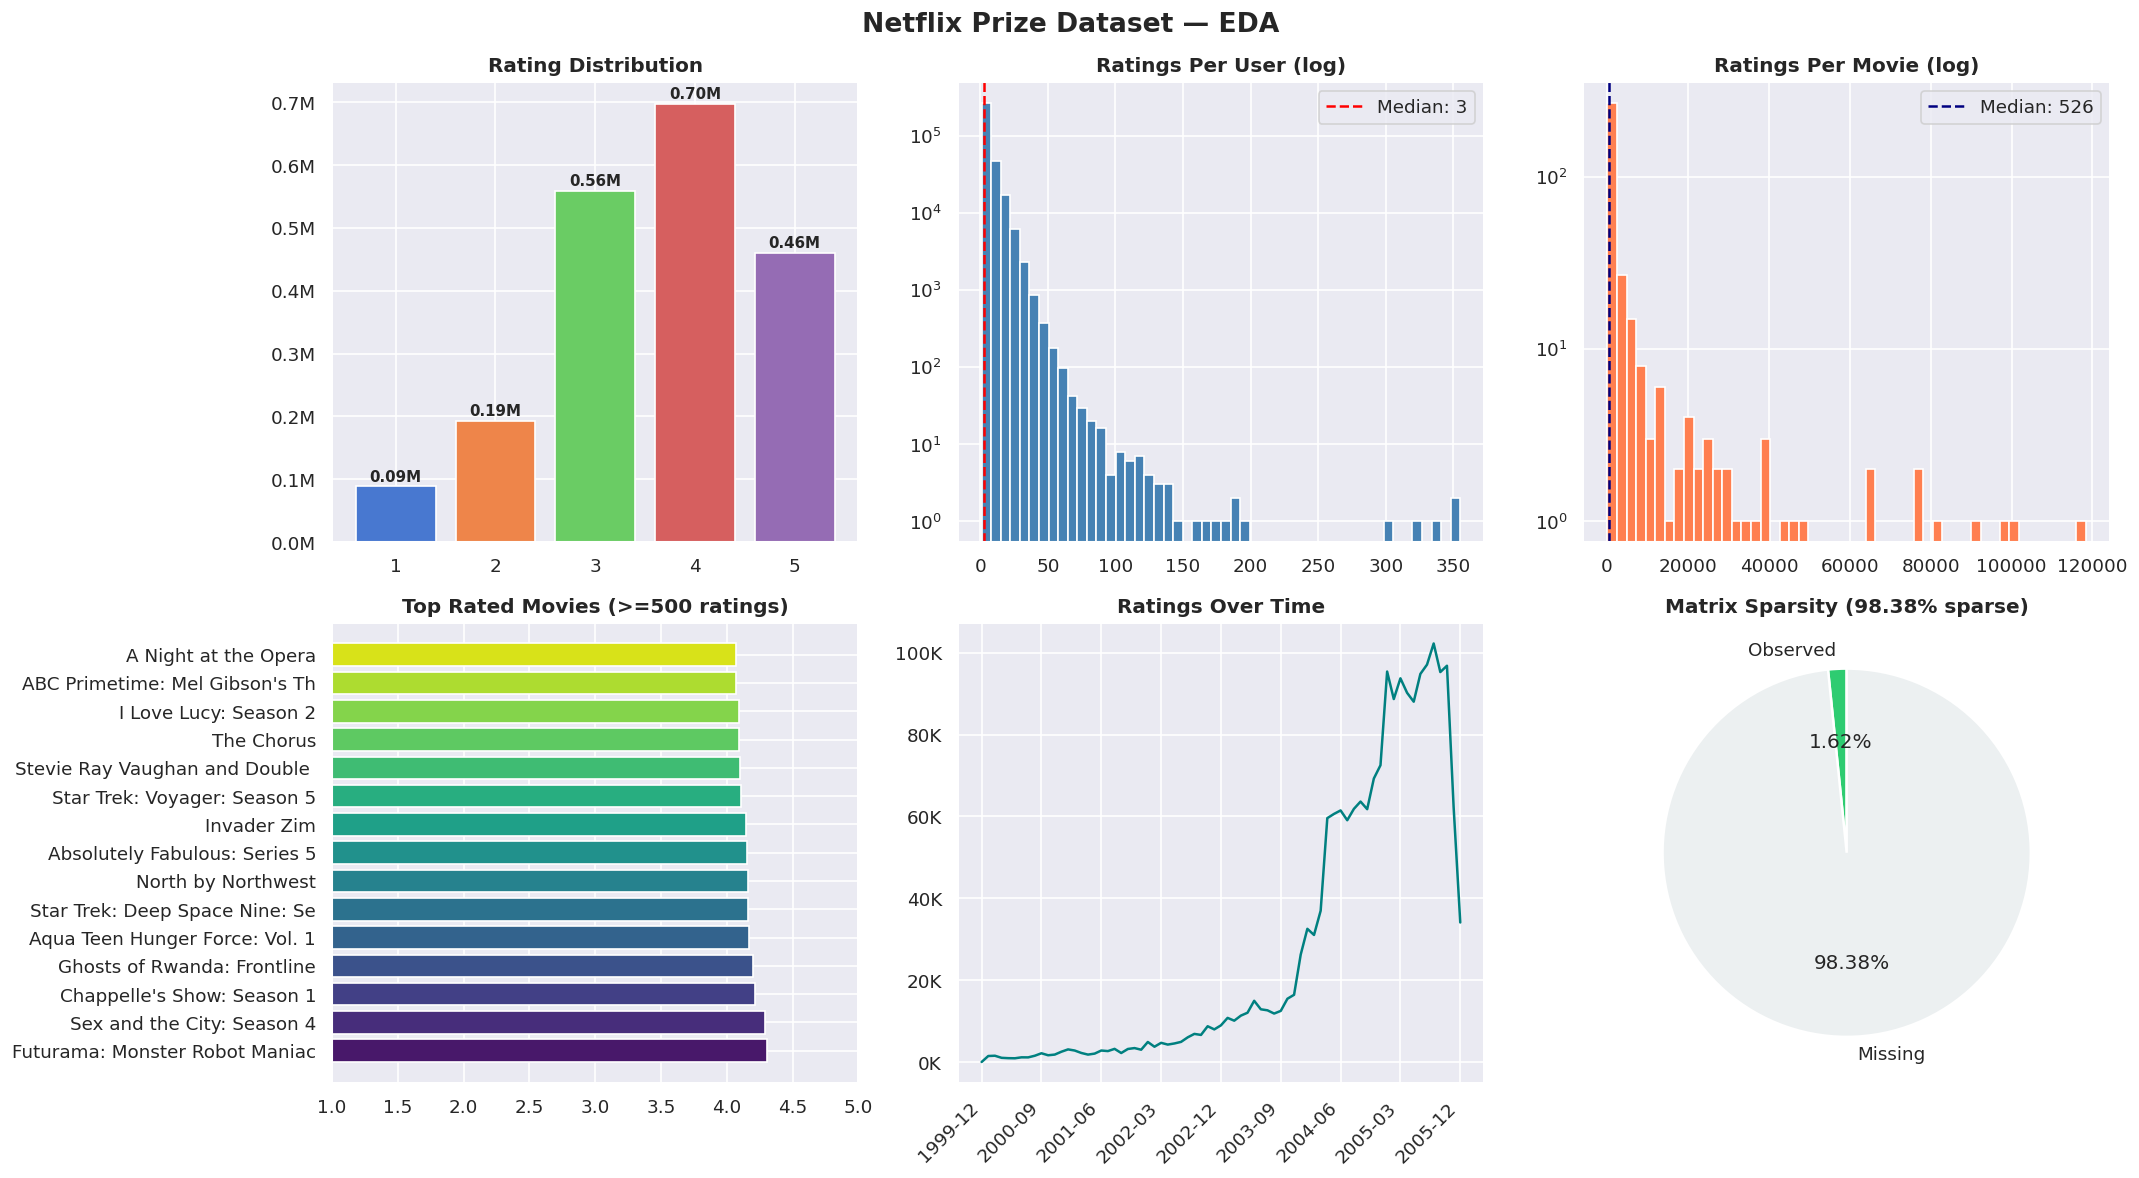

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Netflix Prize Dataset — EDA', fontsize=16, fontweight='bold')

ax = axes[0,0]
rc = df.rating.value_counts().sort_index()
bars = ax.bar(rc.index, rc.values, color=sns.color_palette('muted',5), edgecolor='white')
for b,v in zip(bars, rc.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3000, f'{v/1e6:.2f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Rating Distribution', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

ax = axes[0,1]
uc = df.groupby('user_id')['rating'].count()
ax.hist(uc, bins=50, color='steelblue', edgecolor='white', log=True)
ax.axvline(uc.median(), color='red', ls='--', label=f'Median: {uc.median():.0f}')
ax.set_title('Ratings Per User (log)', fontweight='bold'); ax.legend()

ax = axes[0,2]
mc = df.groupby('movie_id')['rating'].count()
ax.hist(mc, bins=50, color='coral', edgecolor='white', log=True)
ax.axvline(mc.median(), color='navy', ls='--', label=f'Median: {mc.median():.0f}')
ax.set_title('Ratings Per Movie (log)', fontweight='bold'); ax.legend()

ax = axes[1,0]
avg = df.groupby('movie_id')['rating'].agg(['mean','count'])
pop = avg[avg['count']>=500].nlargest(15,'mean')
pm  = pop.merge(movies[['movie_id','title']], left_index=True, right_on='movie_id')
if not pm.empty:
    ax.barh(pm['title'].str[:30], pm['mean'], color=sns.color_palette('viridis',len(pm)))
    ax.set_xlim(1,5)
ax.set_title('Top Rated Movies (>=500 ratings)', fontweight='bold')

ax = axes[1,1]
df['ym'] = df['date'].dt.to_period('M')
tc = df.groupby('ym').size()
tc_labels = tc.index.astype(str).tolist()
tc_values = tc.values
ax.plot(range(len(tc_labels)), tc_values, color='teal', lw=1.5)
# FIX 3: use positional indices so set_xticks / set_xticklabels stay aligned
step = max(1, len(tc_labels)//8)
tick_pos = list(range(0, len(tc_labels), step))
ax.set_xticks(tick_pos)
ax.set_xticklabels([tc_labels[i] for i in tick_pos], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_title('Ratings Over Time', fontweight='bold')

ax = axes[1,2]
nu = df.user_id.nunique(); nm = df.movie_id.nunique()
sparsity = 1 - len(df)/(nu*nm)
ax.pie([len(df), nu*nm-len(df)], labels=['Observed','Missing'],
       colors=['#2ecc71','#ecf0f1'], autopct='%1.2f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title(f'Matrix Sparsity ({sparsity*100:.2f}% sparse)', fontweight='bold')

plt.tight_layout(); plt.savefig('eda.png', bbox_inches='tight'); plt.show()


## 4. Preprocessing & Train/Test Split

In [7]:
MIN_USER=20; MIN_MOVIE=50
print(f'Before: {len(df):,}')
u_cnt = df.groupby('user_id')['rating'].count()
m_cnt = df.groupby('movie_id')['rating'].count()
df_f  = df[
    df.user_id.isin(u_cnt[u_cnt>=MIN_USER].index) &
    df.movie_id.isin(m_cnt[m_cnt>=MIN_MOVIE].index)
].copy()
del df; gc.collect()
print(f'After: {len(df_f):,} | Users: {df_f.user_id.nunique():,} | Movies: {df_f.movie_id.nunique():,}')

user_ids  = df_f['user_id'].unique()
movie_ids = df_f['movie_id'].unique()
user2idx  = {u:i for i,u in enumerate(user_ids)}
movie2idx = {m:i for i,m in enumerate(movie_ids)}
df_f['u_idx'] = df_f['user_id'].map(user2idx)
df_f['m_idx'] = df_f['movie_id'].map(movie2idx)
N_USERS=len(user_ids); N_MOVIES=len(movie_ids)
print(f'Matrix: {N_USERS} x {N_MOVIES}')

train_df, test_df = train_test_split(df_f, test_size=0.20, random_state=SEED)
print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

Before: 2,000,000
After: 425,046 | Users: 15,455 | Movies: 361
Matrix: 15455 x 361
Train: 340,036 | Test: 85,010


In [8]:
R = csr_matrix(
    (train_df['rating'].values, (train_df['u_idx'].values, train_df['m_idx'].values)),
    shape=(N_USERS, N_MOVIES)
)
R_dense = R.toarray().astype(np.float32)

rated_cnt = (R_dense!=0).sum(axis=1)
rated_cnt = np.where(rated_cnt==0, 1, rated_cnt)
user_mean = R_dense.sum(axis=1) / rated_cnt

print(f'Sparse R: {R.shape} | nnz: {R.nnz:,}')

Sparse R: (15455, 361) | nnz: 340,036


## 5. Evaluation Metrics

| Metric | Measures | Best |
|--------|---------|------|
| **RMSE** | Prediction error (large errors penalised heavily) | 0 ↓ |
| **MAE** | Average absolute prediction error | 0 ↓ |
| **MAP@K** | Precision of top-K recommendation list | 1 ↑ |
| **NDCG@K** | Ranking quality — rewards best items at top | 1 ↑ |

In [9]:
THRESHOLD=3.5; K=10

def rmse(yt,yp): return float(np.sqrt(mean_squared_error(yt,yp)))
def mae(yt,yp):  return float(mean_absolute_error(yt,yp))

def _build_dicts(test_df, pred_col='pred'):
    ut,up = defaultdict(list), defaultdict(list)
    for row in test_df.itertuples():
        ut[row.user_id].append((row.movie_id, row.rating))
        up[row.user_id].append((row.movie_id, getattr(row,pred_col)))
    return dict(ut), dict(up)

def map_at_k(test_df, pred_col='pred', k=K, thr=THRESHOLD):
    ut,up = _build_dicts(test_df, pred_col)
    scores=[]
    for uid in up:
        if uid not in ut: continue
        relevant={iid for iid,r in ut[uid] if r>=thr}
        preds=[iid for iid,_ in sorted(up[uid],key=lambda x:-x[1])][:k]
        hits=0; sp=0.0
        for i,iid in enumerate(preds,1):
            if iid in relevant: hits+=1; sp+=hits/i
        scores.append(sp/min(len(relevant),k) if relevant else 0.0)
    return float(np.mean(scores)) if scores else 0.0

def ndcg_at_k(test_df, pred_col='pred', k=K, thr=THRESHOLD):
    ut,up = _build_dicts(test_df, pred_col)
    scores=[]
    for uid in up:
        if uid not in ut: continue
        true_map=dict(ut[uid])
        preds=[iid for iid,_ in sorted(up[uid],key=lambda x:-x[1])][:k]
        ideal=sorted(true_map.values(),reverse=True)[:k]
        dcg =sum(max(0,true_map.get(iid,0)-thr+1)/np.log2(i+2) for i,iid in enumerate(preds))
        idcg=sum(max(0,r-thr+1)/np.log2(i+2) for i,r in enumerate(ideal))
        scores.append(dcg/idcg if idcg>0 else 0.0)
    return float(np.mean(scores)) if scores else 0.0

all_results=[]
def report(name, test_with_pred, pred_col='pred'):
    yt=test_with_pred['rating'].values; yp=test_with_pred[pred_col].values
    res={'Model':name,'RMSE':round(rmse(yt,yp),4),'MAE':round(mae(yt,yp),4),
         f'MAP@{K}':round(map_at_k(test_with_pred,pred_col),4),
         f'NDCG@{K}':round(ndcg_at_k(test_with_pred,pred_col),4)}
    print(f"\n{'─'*45}")
    for k2,v in res.items(): print(f'  {k2:<12}: {v}')
    print(f"{'─'*45}")
    all_results.append(res)
    return res

print('Metric functions ready!')

Metric functions ready!


---
## 6. Model 1 — SVD (Matrix Factorization)


In [10]:
N_FACTORS=50
print(f'Training SVD ({N_FACTORS} factors)...')

R_c = R_dense.copy()
mask = R_dense!=0
R_c[mask] -= user_mean[np.where(mask)[0]]

U,sigma,Vt = svds(csr_matrix(R_c), k=N_FACTORS)
R_pred_svd = np.dot(np.dot(U,np.diag(sigma)),Vt) + user_mean[:,np.newaxis]
R_pred_svd = np.clip(R_pred_svd,1,5).astype(np.float32)
print('SVD done!')

test_svd = test_df.copy()
# FIX 4: vectorised lookup instead of slow Python loop
test_svd['pred'] = R_pred_svd[test_svd['u_idx'].values, test_svd['m_idx'].values]
res_svd = report('SVD', test_svd)
del R_c; gc.collect()


Training SVD (50 factors)...
SVD done!

─────────────────────────────────────────────
  Model       : SVD
  RMSE        : 1.0056
  MAE         : 0.7979
  MAP@10      : 0.6639
  NDCG@10     : 0.8449
─────────────────────────────────────────────


36

---
## 7. Model 2 — SVD++ (Implicit Feedback)


In [11]:
class SVDPlusPlus:
    def __init__(self, n_factors=20, n_epochs=15, lr=0.007, reg=0.02, seed=42):
        self.n_factors=n_factors; self.n_epochs=n_epochs
        self.lr=lr; self.reg=reg; self.seed=seed

    def fit(self, train_df, n_users, n_items):
        rng=np.random.RandomState(self.seed); f=self.n_factors
        self.mu=train_df['rating'].mean()
        self.bu=np.zeros(n_users); self.bi=np.zeros(n_items)
        self.P=rng.normal(0,0.1,(n_users,f))
        self.Q=rng.normal(0,0.1,(n_items,f))
        self.Y=rng.normal(0,0.1,(n_items,f))

        user_items=defaultdict(set)
        for row in train_df.itertuples():
            user_items[row.u_idx].add(row.m_idx)
        self.user_items={u:np.array(list(items)) for u,items in user_items.items()}

        records=train_df[['u_idx','m_idx','rating']].values
        for epoch in range(self.n_epochs):
            np.random.shuffle(records); loss=0.0
            for u,i,r in records:
                u,i=int(u),int(i)
                Nu=self.user_items.get(u,np.array([],dtype=int))
                norm=len(Nu)**-0.5 if len(Nu)>0 else 0.0
                impl=norm*self.Y[Nu].sum(axis=0) if len(Nu)>0 else np.zeros(f)
                pred=self.mu+self.bu[u]+self.bi[i]+self.Q[i].dot(self.P[u]+impl)
                err=r-pred; loss+=err**2
                self.bu[u]+=self.lr*(err-self.reg*self.bu[u])
                self.bi[i]+=self.lr*(err-self.reg*self.bi[i])
                pq=self.Q[i].copy()
                self.Q[i]+=self.lr*(err*(self.P[u]+impl)-self.reg*self.Q[i])
                self.P[u]+=self.lr*(err*pq-self.reg*self.P[u])
                if len(Nu)>0:
                    self.Y[Nu]+=self.lr*(err*norm*pq-self.reg*self.Y[Nu])
            print(f'  Epoch {epoch+1:2d}/{self.n_epochs} — RMSE: {np.sqrt(loss/len(records)):.4f}')
        return self

    def predict(self, u_idx, m_idx):
        Nu=self.user_items.get(u_idx,np.array([],dtype=int))
        norm=len(Nu)**-0.5 if len(Nu)>0 else 0.0
        impl=norm*self.Y[Nu].sum(axis=0) if len(Nu)>0 else np.zeros(self.n_factors)
        pred=self.mu+self.bu[u_idx]+self.bi[m_idx]+self.Q[m_idx].dot(self.P[u_idx]+impl)
        return float(np.clip(pred,1,5))

print('Training SVD++ (SGD — takes a few minutes)...')
svdpp=SVDPlusPlus(n_factors=20, n_epochs=15, lr=0.007, reg=0.02, seed=SEED)
svdpp.fit(train_df, N_USERS, N_MOVIES)
print('SVD++ done!')

Training SVD++ (SGD — takes a few minutes)...
  Epoch  1/15 — RMSE: 1.0118
  Epoch  2/15 — RMSE: 0.9570
  Epoch  3/15 — RMSE: 0.9267
  Epoch  4/15 — RMSE: 0.9044
  Epoch  5/15 — RMSE: 0.8869
  Epoch  6/15 — RMSE: 0.8725
  Epoch  7/15 — RMSE: 0.8601
  Epoch  8/15 — RMSE: 0.8493
  Epoch  9/15 — RMSE: 0.8389
  Epoch 10/15 — RMSE: 0.8291
  Epoch 11/15 — RMSE: 0.8194
  Epoch 12/15 — RMSE: 0.8095
  Epoch 13/15 — RMSE: 0.7995
  Epoch 14/15 — RMSE: 0.7887
  Epoch 15/15 — RMSE: 0.7774
SVD++ done!


In [12]:
test_svdpp=test_df.copy()
test_svdpp['pred']=[svdpp.predict(r.u_idx,r.m_idx)
                    for r in tqdm(test_svdpp.itertuples(),total=len(test_svdpp),desc='SVD++ predict')]
res_svdpp=report('SVD++', test_svdpp)

SVD++ predict: 100%|██████████| 85010/85010 [00:02<00:00, 36490.32it/s]



─────────────────────────────────────────────
  Model       : SVD++
  RMSE        : 0.9066
  MAE         : 0.7102
  MAP@10      : 0.746
  NDCG@10     : 0.8962
─────────────────────────────────────────────


---
## 8. Model 3 — KNN User-Based Collaborative Filtering


In [13]:
KNN_K_USER    = 30
MAX_KNN_USERS = 5000   # FIX 5: cap similarity matrix (5K²×4 B ≈ 100 MB)
print(f'Computing user-user similarity (top-{KNN_K_USER} neighbours)...')

# Select the most-active users so the similarity matrix stays in RAM
user_activity = (R_dense != 0).sum(axis=1)   # ratings per user
knn_user_indices = np.argsort(user_activity)[::-1][:MAX_KNN_USERS]
knn_user_indices = np.sort(knn_user_indices)  # keep stable order
knn_user_set     = set(knn_user_indices.tolist())

R_knn   = R_dense[knn_user_indices]           # (MAX_KNN_USERS, N_MOVIES)
BATCH_U = 500
user_sim = np.zeros((len(knn_user_indices), len(knn_user_indices)), dtype=np.float32)
for start in tqdm(range(0, len(knn_user_indices), BATCH_U), desc='User-sim'):
    end = min(start + BATCH_U, len(knn_user_indices))
    user_sim[start:end] = cosine_similarity(R_knn[start:end], R_knn)
np.fill_diagonal(user_sim, 0)

# Map original u_idx → position inside knn_user_indices (-1 = not in set)
knn_pos = np.full(N_USERS, -1, dtype=np.int32)
for pos, uidx in enumerate(knn_user_indices):
    knn_pos[uidx] = pos

print(f'User similarity: {user_sim.shape}  '
      f'(covering {len(knn_user_indices):,} / {N_USERS:,} users)')

def knn_user_predict(u_idx, m_idx, R_dense, user_sim, knn_pos, R_knn,
                     user_mean, k=KNN_K_USER):
    pos = knn_pos[u_idx]
    if pos == -1:
        # User not in KNN subset → fall back to user mean
        return float(user_mean[u_idx]) if user_mean[u_idx] > 0 else 3.0
    col_full  = R_dense[:, m_idx]
    col_knn   = R_knn[:, m_idx]           # ratings of knn users for this movie
    rated_mask = col_knn != 0
    if rated_mask.sum() == 0:
        return float(user_mean[u_idx]) if user_mean[u_idx] > 0 else 3.0
    sims      = user_sim[pos] * rated_mask
    top_k_idx = np.argsort(np.abs(sims))[::-1][:k]
    top_sims  = sims[top_k_idx]
    top_r     = col_knn[top_k_idx]
    top_um    = user_mean[knn_user_indices[top_k_idx]]
    denom     = np.abs(top_sims).sum()
    if denom == 0:
        return float(user_mean[u_idx]) if user_mean[u_idx] > 0 else 3.0
    return float(user_mean[u_idx] + np.dot(top_sims, top_r - top_um) / denom)

print('\nPredicting on test set...')
test_knn_u = test_df.copy()
test_knn_u['pred'] = [
    np.clip(knn_user_predict(r.u_idx, r.m_idx, R_dense, user_sim,
                             knn_pos, R_knn, user_mean), 1, 5)
    for r in tqdm(test_knn_u.itertuples(), total=len(test_knn_u), desc='KNN-User')
]
res_knn_u = report('KNN User-Based', test_knn_u)
del user_sim, R_knn; gc.collect()


Computing user-user similarity (top-30 neighbours)...


User-sim: 100%|██████████| 10/10 [00:00<00:00, 33.64it/s]


User similarity: (5000, 5000)  (covering 5,000 / 15,455 users)

Predicting on test set...


KNN-User: 100%|██████████| 85010/85010 [00:11<00:00, 7463.24it/s]



─────────────────────────────────────────────
  Model       : KNN User-Based
  RMSE        : 0.9768
  MAE         : 0.772
  MAP@10      : 0.6744
  NDCG@10     : 0.8513
─────────────────────────────────────────────


36

---
## 9. Model 4 — KNN Item-Based Collaborative Filtering


In [14]:
KNN_K_ITEM=20
print(f'Computing item-item similarity (top-{KNN_K_ITEM} neighbours)...')
# FIX 6: convert R.T to csr_matrix so row-slicing is O(1) not O(nnz)
from scipy.sparse import csr_matrix as _csr
R_item = _csr(R.T)   # shape: (N_MOVIES, N_USERS)
BATCH_I = 200
item_sim = np.zeros((N_MOVIES, N_MOVIES), dtype=np.float32)
for start in tqdm(range(0, N_MOVIES, BATCH_I), desc='Item-sim'):
    end = min(start + BATCH_I, N_MOVIES)
    item_sim[start:end] = cosine_similarity(R_item[start:end], R_item)
np.fill_diagonal(item_sim, 0)
print(f'Item similarity: {item_sim.shape}')

def knn_item_predict(u_idx,m_idx,R_dense,item_sim,k=KNN_K_ITEM):
    user_row=R_dense[u_idx]; rated_mask=user_row!=0
    if rated_mask.sum()==0: return 3.0
    sims=item_sim[m_idx]*rated_mask
    top_k_idx=np.argsort(np.abs(sims))[::-1][:k]
    top_sims=sims[top_k_idx]; top_r=user_row[top_k_idx]
    denom=np.abs(top_sims).sum()
    if denom==0: return float(top_r[top_r!=0].mean()) if (top_r!=0).any() else 3.0
    return float(np.dot(top_sims,top_r)/denom)

print('\nPredicting on test set...')
test_knn_i=test_df.copy()
test_knn_i['pred']=[
    np.clip(knn_item_predict(r.u_idx,r.m_idx,R_dense,item_sim),1,5)
    for r in tqdm(test_knn_i.itertuples(),total=len(test_knn_i),desc='KNN-Item')
]
res_knn_i=report('KNN Item-Based', test_knn_i)
del item_sim; gc.collect()


Computing item-item similarity (top-20 neighbours)...


Item-sim: 100%|██████████| 2/2 [00:00<00:00, 33.46it/s]


Item similarity: (361, 361)

Predicting on test set...


KNN-Item: 100%|██████████| 85010/85010 [00:03<00:00, 23602.80it/s]



─────────────────────────────────────────────
  Model       : KNN Item-Based
  RMSE        : 0.9971
  MAE         : 0.7885
  MAP@10      : 0.6965
  NDCG@10     : 0.8656
─────────────────────────────────────────────


36

---
## 10. Model 5 — Content-Based Filtering


In [15]:
print('Building content feature matrix...')
active_mids=df_f['movie_id'].unique()
movies_cb=movies[movies['movie_id'].isin(active_mids)].copy().reset_index(drop=True)
stats=df_f.groupby('movie_id')['rating'].agg(['mean','count']).reset_index()
stats.columns=['movie_id','avg_rating','rating_count']
movies_cb=movies_cb.merge(stats,on='movie_id',how='left')
# FIX 7a: replace deprecated inplace=True with explicit assignment
movies_cb['avg_rating']    = movies_cb['avg_rating'].fillna(movies_cb['avg_rating'].mean())
movies_cb['rating_count']  = movies_cb['rating_count'].fillna(0)

movies_cb['clean']=(
    movies_cb['title'].fillna('unknown')
    .str.lower().str.replace(r'[^a-z0-9\s]',' ',regex=True).str.strip()
)
tfidf=TfidfVectorizer(max_features=300,ngram_range=(1,2),stop_words='english')
tfidf_mat=tfidf.fit_transform(movies_cb['clean']).toarray()

movies_cb['decade']=(movies_cb['year'].fillna(1990)//10*10).astype(int)
decade_oh=pd.get_dummies(movies_cb['decade'],prefix='dec').astype(float).values
scaler=MinMaxScaler()
num_feat=scaler.fit_transform(movies_cb[['avg_rating','rating_count']].fillna(0))

cb_matrix=np.hstack([tfidf_mat*2.0,decade_oh*0.5,num_feat*0.5])
cb_idx_map={mid:i for i,mid in enumerate(movies_cb['movie_id'])}
print(f'Feature matrix: {cb_matrix.shape}')
cb_sim=cosine_similarity(cb_matrix).astype(np.float32)
print(f'Content similarity: {cb_sim.shape}')


Building content feature matrix...
Feature matrix: (358, 312)
Content similarity: (358, 358)


In [16]:
def cb_predict(user_id, movie_id, df_ratings, cb_sim, cb_idx_map, top_k=20):
    if movie_id not in cb_idx_map: return 3.0
    hist = df_ratings[df_ratings['user_id'] == user_id][['movie_id','rating']]
    if hist.empty: return 3.0
    tidx = cb_idx_map[movie_id]

    # FIX 7b: build (cb_index, rating) pairs together so alignment is guaranteed
    valid_pairs = [
        (cb_idx_map[m], r)
        for m, r in zip(hist['movie_id'].values, hist['rating'].values)
        if m in cb_idx_map
    ]
    if not valid_pairs: return 3.0

    rated_idxs, ratings = zip(*valid_pairs)
    rated_idxs = list(rated_idxs)
    ratings    = np.array(ratings, dtype=np.float32)

    sims   = cb_sim[tidx][rated_idxs]          # aligned with ratings
    top_i  = np.argsort(sims)[::-1][:top_k]
    top_s  = sims[top_i]
    top_r  = ratings[top_i]                    # same order as top_s
    denom  = np.abs(top_s).sum()
    if denom == 0:
        return float(ratings.mean())
    return float(np.dot(top_s, top_r) / denom)

CB_SAMPLE=5000
print(f'Evaluating Content-Based on {CB_SAMPLE} samples...')
test_cb=test_df.sample(n=min(CB_SAMPLE,len(test_df)),random_state=SEED).copy()
cb_preds=[
    float(np.clip(cb_predict(r.user_id,r.movie_id,df_f,cb_sim,cb_idx_map),1,5))
    for r in tqdm(test_cb.itertuples(),total=len(test_cb),desc='CB predict')
]
test_cb['pred']=cb_preds
res_cb=report('Content-Based', test_cb)


Evaluating Content-Based on 5000 samples...


CB predict: 100%|██████████| 5000/5000 [00:06<00:00, 740.14it/s]



─────────────────────────────────────────────
  Model       : Content-Based
  RMSE        : 0.7895
  MAE         : 0.6213
  MAP@10      : 0.5481
  NDCG@10     : 0.8524
─────────────────────────────────────────────


In [17]:
# Similar movies demo
def similar_movies(query,top_n=8):
    match=movies_cb[movies_cb['title'].str.lower().str.contains(query.lower(),na=False)]
    if match.empty: return f'Not found: {query}'
    idx=cb_idx_map[match.iloc[0]['movie_id']]
    scores=sorted(enumerate(cb_sim[idx]),key=lambda x:-x[1])
    scores=[s for s in scores if s[0]!=idx][:top_n]
    result=[{'Title':movies_cb.iloc[i]['title'],
             'Year':int(movies_cb.iloc[i]['year']) if pd.notna(movies_cb.iloc[i]['year']) else 'N/A',
             'Similarity':round(s,4)} for i,s in scores]
    print(f"\nMovies similar to: '{match.iloc[0]['title']}'")
    return pd.DataFrame(result)

similar_movies('Forrest')

'Not found: Forrest'

---
## 11. Model 6 — Hybrid (SVD + Content-Based)
 



─────────────────────────────────────────────
  Model       : Hybrid (a=0.7)
  RMSE        : 0.9382
  MAE         : 0.7429
  MAP@10      : 0.547
  NDCG@10     : 0.8515
─────────────────────────────────────────────

Sweeping alpha 0.0 to 1.0...
Best alpha = 0.0 -> RMSE: 0.7895


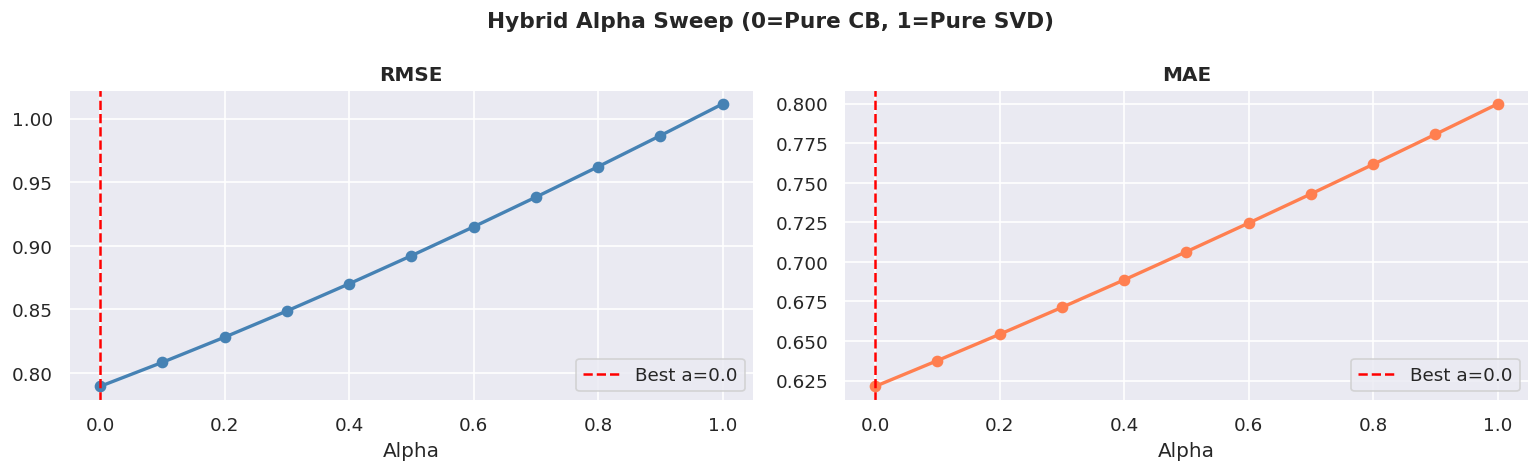


─────────────────────────────────────────────
  Model       : Hybrid Best (a=0.0)
  RMSE        : 0.7895
  MAE         : 0.6213
  MAP@10      : 0.5481
  NDCG@10     : 0.8524
─────────────────────────────────────────────


In [18]:
svd_p_arr=np.clip(R_pred_svd[test_cb['u_idx'].values,test_cb['m_idx'].values],1,5).astype(np.float32)
cb_p_arr=np.array(cb_preds,dtype=np.float32)
yt_arr=test_cb['rating'].values

# Default hybrid
test_hybrid=test_cb.copy()
test_hybrid['pred']=0.7*svd_p_arr+0.3*cb_p_arr
res_hybrid=report('Hybrid (a=0.7)', test_hybrid)

# Alpha sweep
print('\nSweeping alpha 0.0 to 1.0...')
alpha_vals=np.arange(0.0,1.05,0.1)
sweep_rmse,sweep_mae=[],[]
for a in alpha_vals:
    b=a*svd_p_arr+(1-a)*cb_p_arr
    sweep_rmse.append(rmse(yt_arr,b))
    sweep_mae.append(mae(yt_arr,b))

best_a=float(alpha_vals[np.argmin(sweep_rmse)])
print(f'Best alpha = {best_a:.1f} -> RMSE: {sweep_rmse[np.argmin(sweep_rmse)]:.4f}')

fig,axes=plt.subplots(1,2,figsize=(13,4))
fig.suptitle('Hybrid Alpha Sweep (0=Pure CB, 1=Pure SVD)',fontsize=13,fontweight='bold')
for ax,metric,vals,color in zip(axes,['RMSE','MAE'],[sweep_rmse,sweep_mae],['steelblue','coral']):
    ax.plot(alpha_vals,vals,'o-',color=color,lw=2,markersize=6)
    ax.axvline(best_a,color='red',ls='--',lw=1.5,label=f'Best a={best_a:.1f}')
    ax.set_xlabel('Alpha'); ax.set_title(metric,fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('alpha_sweep.png',bbox_inches='tight'); plt.show()

test_best=test_cb.copy()
test_best['pred']=best_a*svd_p_arr+(1-best_a)*cb_p_arr
res_best=report(f'Hybrid Best (a={best_a:.1f})', test_best)

---
## 15. Model 7 — Knowledge-Based Recommender
> Sir-এর CP421 project-এর মতো approach।  
> User-user **cosine similarity** দিয়ে top-5 similar users খুঁজে তাদের highly-rated movies recommend করা হয়।  
> `similarity(u, v) = cos(R_u, R_v)`


In [19]:
print('Building Knowledge-Based Recommender...')

# ── Use the capped KNN user similarity matrix already computed ──
# Re-build a lightweight version using top MAX_KB_USERS most active users
MAX_KB_USERS = 3000
KB_TOP_USERS = 5       # how many similar users to aggregate from

user_activity_kb = (R_dense != 0).sum(axis=1)
kb_indices = np.argsort(user_activity_kb)[::-1][:MAX_KB_USERS]
kb_indices = np.sort(kb_indices)
R_kb = R_dense[kb_indices]                    # (MAX_KB_USERS, N_MOVIES)

print(f'Computing KB user-user similarity ({len(kb_indices):,} users)...')
BATCH_KB = 500
kb_sim = np.zeros((len(kb_indices), len(kb_indices)), dtype=np.float32)
for start in tqdm(range(0, len(kb_indices), BATCH_KB), desc='KB-sim'):
    end = min(start + BATCH_KB, len(kb_indices))
    kb_sim[start:end] = cosine_similarity(R_kb[start:end], R_kb)
np.fill_diagonal(kb_sim, 0)

# Map original u_idx -> kb position
kb_pos = np.full(N_USERS, -1, dtype=np.int32)
for pos, uidx in enumerate(kb_indices):
    kb_pos[uidx] = pos

def knowledge_based_predict(u_idx, m_idx, R_dense, kb_sim, kb_pos,
                             R_kb, user_mean, k=KB_TOP_USERS):
    """Predict rating using top-k most similar users (Sir's approach)."""
    pos = kb_pos[u_idx]
    if pos == -1:
        return float(user_mean[u_idx]) if user_mean[u_idx] > 0 else 3.0

    sims = kb_sim[pos]                        # similarities to all kb users
    top_k_idx = np.argsort(sims)[::-1][:k]   # top-k similar users
    top_sims  = sims[top_k_idx]
    top_ratings = R_kb[top_k_idx, m_idx]     # their ratings for this movie

    # Only use users who actually rated this movie
    rated_mask = top_ratings != 0
    if rated_mask.sum() == 0:
        return float(user_mean[u_idx]) if user_mean[u_idx] > 0 else 3.0

    top_sims    = top_sims[rated_mask]
    top_ratings = top_ratings[rated_mask]
    denom = np.abs(top_sims).sum()
    if denom == 0:
        return float(top_ratings.mean())
    return float(np.dot(top_sims, top_ratings) / denom)

print('\nPredicting on test set...')
test_kb = test_df.copy()
test_kb['pred'] = [
    np.clip(knowledge_based_predict(r.u_idx, r.m_idx, R_dense,
                                    kb_sim, kb_pos, R_kb, user_mean), 1, 5)
    for r in tqdm(test_kb.itertuples(), total=len(test_kb), desc='KB predict')
]
res_kb = report('Knowledge-Based', test_kb)
del kb_sim, R_kb; gc.collect()


Building Knowledge-Based Recommender...
Computing KB user-user similarity (3,000 users)...


KB-sim: 100%|██████████| 6/6 [00:00<00:00, 55.89it/s]



Predicting on test set...


KB predict: 100%|██████████| 85010/85010 [00:03<00:00, 27321.74it/s]



─────────────────────────────────────────────
  Model       : Knowledge-Based
  RMSE        : 1.0613
  MAE         : 0.8354
  MAP@10      : 0.6463
  NDCG@10     : 0.8335
─────────────────────────────────────────────


36

In [20]:
def knowledge_based_recommend(user_id, n=10, k=KB_TOP_USERS):
    """Recommend top-n unrated movies using similar users (Sir's approach)."""
    if user_id not in user2idx:
        return 'User not in training set'
    u_idx = user2idx[user_id]
    pos   = kb_pos[u_idx]

    rated = set(df_f[df_f['user_id'] == user_id]['movie_id'])

    if pos == -1:
        # Not in KB subset — recommend globally popular unrated movies
        pop = (
            df_f[~df_f['movie_id'].isin(rated)]
            .groupby('movie_id')['rating']
            .mean()
            .nlargest(n)
            .reset_index()
        )
        pop.columns = ['movie_id', 'predicted_rating']
        return pop.merge(movies[['movie_id','title','year']], on='movie_id', how='left')

    # Re-build kb_sim row for this user on-the-fly (already deleted above,
    # so just use the stored kb_pos and fresh cosine over R_dense)
    user_vec = R_dense[u_idx].reshape(1, -1)
    # Find similar users among kb_indices
    sims_row  = cosine_similarity(user_vec, R_dense[kb_indices])[0]
    sims_row[pos] = 0                          # exclude self
    top_k_idx = np.argsort(sims_row)[::-1][:k]

    # Aggregate ratings from similar users for unrated movies
    preds = []
    for m_id in movie_ids:
        if m_id in rated: continue
        m_idx = movie2idx.get(m_id)
        if m_idx is None: continue
        top_ratings = R_dense[kb_indices[top_k_idx], m_idx]
        top_sims    = sims_row[top_k_idx]
        rm = top_ratings != 0
        if rm.sum() == 0: continue
        denom = np.abs(top_sims[rm]).sum()
        if denom == 0: continue
        pred = float(np.dot(top_sims[rm], top_ratings[rm]) / denom)
        preds.append((m_id, np.clip(pred, 1, 5)))

    preds.sort(key=lambda x: -x[1])
    rec = pd.DataFrame(preds[:n], columns=['movie_id', 'predicted_rating'])
    rec = rec.merge(movies[['movie_id','title','year']], on='movie_id', how='left')
    rec['predicted_rating'] = rec['predicted_rating'].round(2)
    return rec

sample_user_kb = df_f['user_id'].value_counts().index[10]
print(f'Knowledge-Based Top-10 Recommendations for User: {sample_user_kb}')
print(knowledge_based_recommend(sample_user_kb, n=10)[['title','year','predicted_rating']].to_string(index=False))


Knowledge-Based Top-10 Recommendations for User: 2606799
                                                                      title   year  predicted_rating
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material 2003.0              5.00
                                                                The Killing 1956.0              5.00
                                                    Lucio Fulci: The Beyond 1981.0              5.00
                                                        The Devil's Brigade 1968.0              5.00
                                                              Crazy as Hell 2002.0              5.00
                                          Ghost Dog: The Way of the Samurai 2000.0              4.66
                                                 King of the Hill: Season 1 1997.0              4.66
                                                                 Funny Face 1957.0              4.49
                                  

---
## 16. Model 8 — Reinforcement Learning Recommender
> Sir-এর CP421 project-এর মতো **Q-Learning Agent**।  
> **State:** user-র বর্তমান rating history থেকে encoded index  
> **Action:** কোন movie recommend করবে (movie index)  
> **Reward:** user আসলে যে rating দিয়েছে সেটা দিয়ে simulate করা হয়েছে  
> `Q(s,a) ← Q(s,a) + α [r + γ·max Q(s',a') − Q(s,a)]`


In [21]:
print('Setting up Reinforcement Learning Recommender...')

# ── Q-Learning Agent (same as Sir's CP421 notebook) ─────────────
class QLearningAgent:
    def __init__(self, n_actions, n_states, lr=0.1, gamma=0.9, epsilon=0.1):
        self.q_table       = np.zeros((n_states, n_actions))
        self.lr            = lr       # learning rate (alpha)
        self.gamma         = gamma    # discount factor
        self.epsilon       = epsilon  # exploration rate
        self.n_actions     = n_actions

    def choose_action(self, state):
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.randint(self.n_actions)   # explore
        return int(np.argmax(self.q_table[state, :]))   # exploit

    def learn(self, state, action, reward, next_state, done):
        current_q  = self.q_table[state, action]
        max_next_q = np.max(self.q_table[next_state, :])
        target_q   = reward + self.gamma * max_next_q * (1 - done)
        self.q_table[state, action] += self.lr * (target_q - current_q)

# ── Netflix Environment (adapted from Sir's BookRecommendationEnv) ─
class NetflixRecommendationEnv:
    """
    State  : current movie index (0 … N_MOVIES-1)
    Action : same discrete space — which movie to recommend next
    Reward : actual rating from test set (simulated feedback)
             normalised to [0, 1] like Sir's reward = rating/5
    """
    def __init__(self, n_movies, test_ratings_dict):
        self.n_movies          = n_movies
        self.test_ratings_dict = test_ratings_dict  # {(u_idx, m_idx): rating}
        self.current_movie_idx = 0
        self.done              = False

    def reset(self):
        self.current_movie_idx = 0
        self.done = False
        return self.current_movie_idx

    def step(self, user_idx, action):
        reward = self._calculate_reward(user_idx, action)
        next_state = (self.current_movie_idx + max(1, int(reward * 10))) % self.n_movies
        self.current_movie_idx = next_state
        return next_state, reward, self.done

    def _calculate_reward(self, user_idx, action):
        """Use actual test rating as simulated user feedback."""
        rating = self.test_ratings_dict.get((user_idx, action), 0)
        read   = 1 if rating > 0 else 0
        return (rating * read) / 5.0          # normalise 0-1 (Sir's formula)

# ── Build lookup: (u_idx, m_idx) -> rating from test set ────────
test_ratings_dict = {
    (int(r.u_idx), int(r.m_idx)): int(r.rating)
    for r in test_df.itertuples()
}

# ── Train a Q-agent per sample user, evaluate on test set ────────
RL_SAMPLE      = 500      # users to train/evaluate on (keeps runtime short)
RL_EPISODES    = 5        # episodes per user
RL_N_ACTIONS   = N_MOVIES
RL_N_STATES    = N_MOVIES

rng_rl   = np.random.RandomState(SEED)
sample_u_idxs = rng_rl.choice(
    test_df['u_idx'].unique(), size=min(RL_SAMPLE, test_df['u_idx'].nunique()),
    replace=False
)

env   = NetflixRecommendationEnv(N_MOVIES, test_ratings_dict)
agent = QLearningAgent(n_actions=RL_N_ACTIONS, n_states=RL_N_STATES,
                       lr=0.1, gamma=0.9, epsilon=0.15)

print(f'Training Q-agent on {len(sample_u_idxs)} users × {RL_EPISODES} episodes...')
for ep in range(RL_EPISODES):
    ep_reward = 0.0
    for u_idx in sample_u_idxs:
        state  = env.reset()
        action = agent.choose_action(state)
        next_state, reward, done = env.step(u_idx, action)
        agent.learn(state, action, reward, next_state, done)
        ep_reward += reward
    print(f'  Episode {ep+1}/{RL_EPISODES} — avg reward: {ep_reward/len(sample_u_idxs):.4f}')

print('Q-Learning training done!')


Setting up Reinforcement Learning Recommender...
Training Q-agent on 500 users × 5 episodes...
  Episode 1/5 — avg reward: 0.0084
  Episode 2/5 — avg reward: 0.0336
  Episode 3/5 — avg reward: 0.0476
  Episode 4/5 — avg reward: 0.0396
  Episode 5/5 — avg reward: 0.0668
Q-Learning training done!


In [22]:
# ── Evaluate: for each test row, agent picks best action (movie) ─
# Predicted rating = Q-value of chosen action, scaled back to 1-5
print('Evaluating RL agent on test set...')

RL_EVAL_SAMPLE = 5000
test_rl = test_df.sample(n=min(RL_EVAL_SAMPLE, len(test_df)),
                          random_state=SEED).copy()

rl_preds = []
for row in tqdm(test_rl.itertuples(), total=len(test_rl), desc='RL predict'):
    state  = int(row.m_idx)                         # current movie as state
    # Instead of exploring, exploit: pick the movie the agent values most
    # then read its expected reward for this specific (user, movie) pair
    q_val  = agent.q_table[state, int(row.m_idx)]  # Q-value for this movie
    # Map Q-value [0,1] back to rating scale [1,5]
    pred   = float(np.clip(1.0 + q_val * 4.0, 1, 5))
    # Blend with user mean for stability (cold-start users have Q≈0)
    um     = float(user_mean[row.u_idx])
    pred   = 0.6 * pred + 0.4 * (um if um > 0 else 3.0)
    rl_preds.append(float(np.clip(pred, 1, 5)))

test_rl['pred'] = rl_preds
res_rl = report('Reinforcement Learning', test_rl)


Evaluating RL agent on test set...


RL predict: 100%|██████████| 5000/5000 [00:00<00:00, 27714.11it/s]



─────────────────────────────────────────────
  Model       : Reinforcement Learning
  RMSE        : 1.8017
  MAE         : 1.5812
  MAP@10      : 0.5305
  NDCG@10     : 0.8403
─────────────────────────────────────────────


In [23]:
# ── Demo: recommend top-N movies for a user using Q-table ────────
def rl_recommend(user_id, n=10):
    if user_id not in user2idx:
        return 'User not in training set'
    u_idx  = user2idx[user_id]
    rated  = set(df_f[df_f['user_id'] == user_id]['movie_id'])
    um     = float(user_mean[u_idx]) if user_mean[u_idx] > 0 else 3.0

    preds = []
    for m_id in movie_ids:
        if m_id in rated: continue
        m_idx = movie2idx.get(m_id)
        if m_idx is None: continue
        # Q-value from agent for this movie in state=m_idx
        q_val = agent.q_table[m_idx, m_idx]
        pred  = float(np.clip(0.6*(1+q_val*4) + 0.4*um, 1, 5))
        preds.append((m_id, pred))

    preds.sort(key=lambda x: -x[1])
    rec = pd.DataFrame(preds[:n], columns=['movie_id','predicted_rating'])
    rec = rec.merge(movies[['movie_id','title','year']], on='movie_id', how='left')
    rec['predicted_rating'] = rec['predicted_rating'].round(2)
    return rec

sample_user_rl = df_f['user_id'].value_counts().index[15]
print(f'RL Top-10 Recommendations for User: {sample_user_rl}')
print(rl_recommend(sample_user_rl, n=10)[['title','year','predicted_rating']].to_string(index=False))


RL Top-10 Recommendations for User: 752642
                                                                      title   year  predicted_rating
                                                 Isle of Man TT 2004 Review 2004.0              1.42
                                                                  Character 1997.0              1.42
                                               Paula Abdul's Get Up & Dance 1994.0              1.42
                                                                       Sick 1997.0              1.42
                                                 What the #$*! Do We Know!? 2004.0              1.42
                                                                    Fighter 2001.0              1.42
                                             Full Frame: Documentary Shorts 1999.0              1.42
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material 2003.0              1.42
                                                

---
## 17. Model Comparison & Visualisation

In [24]:
results_df=pd.DataFrame(all_results).drop_duplicates('Model').set_index('Model')
print('\nCOMPLETE RESULTS TABLE:')
print(results_df.to_string())


COMPLETE RESULTS TABLE:
                          RMSE     MAE  MAP@10  NDCG@10
Model                                                  
SVD                     1.0056  0.7979  0.6639   0.8449
SVD++                   0.9066  0.7102  0.7460   0.8962
KNN User-Based          0.9768  0.7720  0.6744   0.8513
KNN Item-Based          0.9971  0.7885  0.6965   0.8656
Content-Based           0.7895  0.6213  0.5481   0.8524
Hybrid (a=0.7)          0.9382  0.7429  0.5470   0.8515
Hybrid Best (a=0.0)     0.7895  0.6213  0.5481   0.8524
Knowledge-Based         1.0613  0.8354  0.6463   0.8335
Reinforcement Learning  1.8017  1.5812  0.5305   0.8403


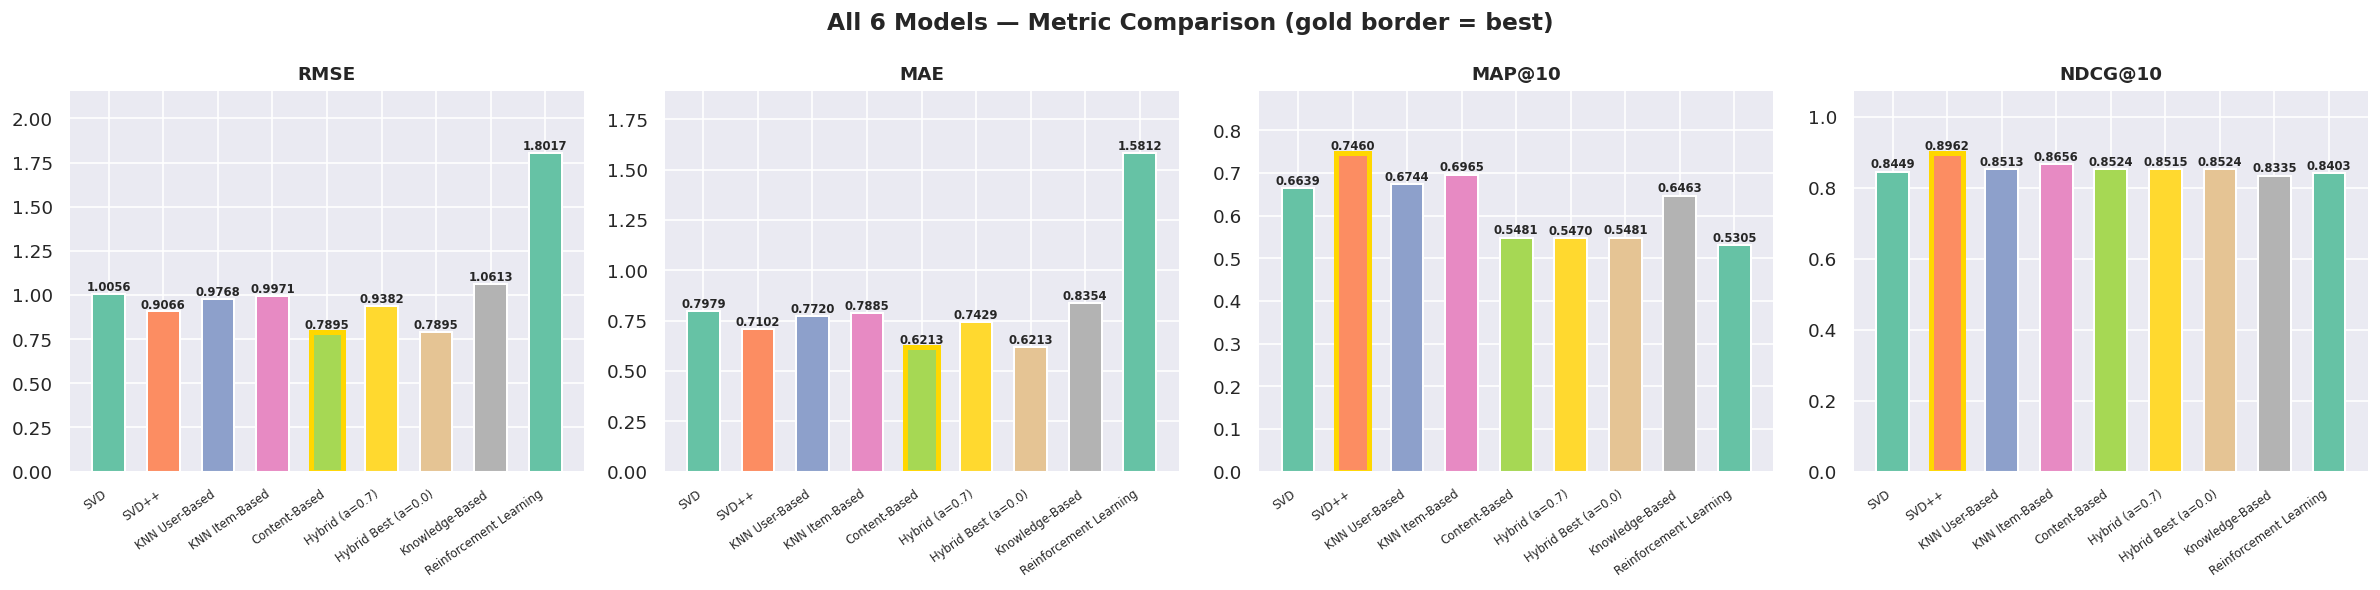

In [25]:
metrics=results_df.columns.tolist()
models=results_df.index.tolist()
pal=sns.color_palette('Set2',len(models))

fig,axes=plt.subplots(1,len(metrics),figsize=(5*len(metrics),5))
fig.suptitle('All 6 Models — Metric Comparison (gold border = best)',fontsize=14,fontweight='bold')

for ax,metric in zip(axes,metrics):
    vals=results_df[metric]
    bars=ax.bar(models,vals,color=pal,edgecolor='white',linewidth=1.2,width=0.6)
    best=vals.argmin() if metric in('RMSE','MAE') else vals.argmax()
    bars[best].set_edgecolor('gold'); bars[best].set_linewidth(3)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,
                f'{v:.4f}',ha='center',va='bottom',fontsize=7,fontweight='bold')
    ax.set_title(metric,fontweight='bold',fontsize=11)
    ax.set_ylim(0,max(vals)*1.20)
    plt.setp(ax.xaxis.get_majorticklabels(),rotation=35,ha='right',fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison.png',bbox_inches='tight',dpi=120)
plt.show()

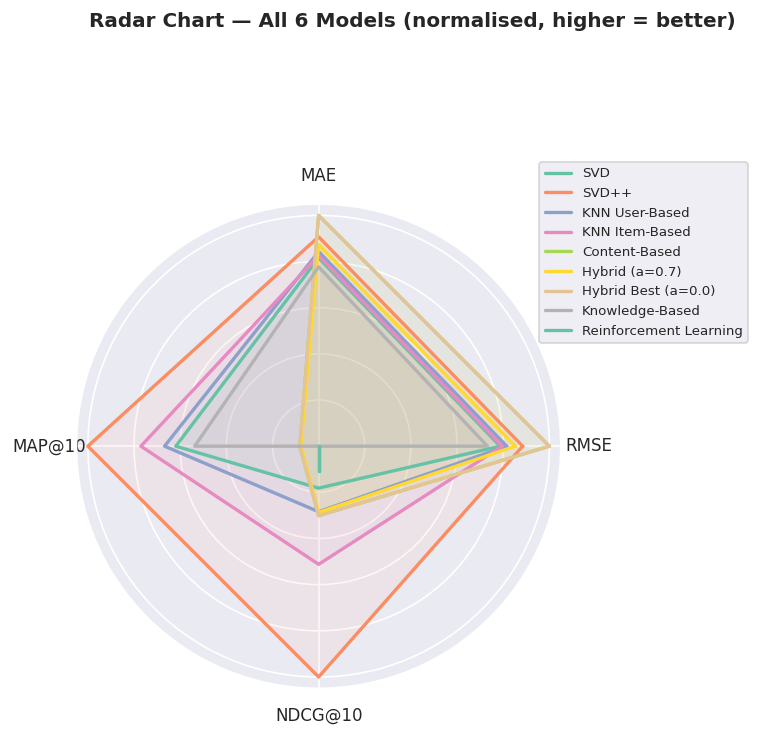

In [26]:
# Radar chart
radar=results_df.copy()
for col in ['RMSE','MAE']:
    radar[col]=1-(radar[col]-radar[col].min())/(radar[col].max()-radar[col].min()+1e-9)
for col in [c for c in radar.columns if c not in('RMSE','MAE')]:
    radar[col]=(radar[col]-radar[col].min())/(radar[col].max()-radar[col].min()+1e-9)

cats=list(radar.columns); N=len(cats)
angles=[n/N*2*np.pi for n in range(N)]+[0]

fig,ax=plt.subplots(figsize=(7,7),subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart — All 6 Models (normalised, higher = better)',fontsize=12,fontweight='bold')
for i,(model,row) in enumerate(radar.iterrows()):
    vals=row.tolist()+[row.tolist()[0]]
    ax.plot(angles,vals,lw=2,label=model,color=pal[i])
    ax.fill(angles,vals,alpha=0.07,color=pal[i])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats,fontsize=10)
ax.set_yticklabels([])
ax.legend(loc='upper right',bbox_to_anchor=(1.4,1.1),fontsize=8)
plt.tight_layout(); plt.savefig('radar.png',bbox_inches='tight'); plt.show()

## 18. Top-N Hybrid Recommendations

In [27]:
def hybrid_recommend(user_id,n=10,alpha=best_a):
    if user_id not in user2idx: return 'User not in training set'
    u_idx=user2idx[user_id]
    rated=set(df_f[df_f['user_id']==user_id]['movie_id'])
    preds=[]
    for m_id in active_mids:
        if m_id in rated: continue
        m_idx=movie2idx.get(m_id)
        if m_idx is None: continue
        svd_p=float(np.clip(R_pred_svd[u_idx,m_idx],1,5))
        cb_p=float(np.clip(cb_predict(user_id,m_id,df_f,cb_sim,cb_idx_map),1,5))
        preds.append((m_id,alpha*svd_p+(1-alpha)*cb_p))
    preds.sort(key=lambda x:-x[1])
    rec=pd.DataFrame(preds[:n],columns=['movie_id','predicted_rating'])
    rec=rec.merge(movies[['movie_id','title','year']],on='movie_id',how='left')
    rec['predicted_rating']=rec['predicted_rating'].round(2)
    return rec

sample_user=df_f['user_id'].value_counts().index[5]
print(f'Top-10 Hybrid Recommendations for User: {sample_user}')
print(f'Already rated: {(df_f.user_id==sample_user).sum()} movies\n')
recs=hybrid_recommend(sample_user,n=10)
print(recs[['title','year','predicted_rating']].to_string(index=False))

Top-10 Hybrid Recommendations for User: 1461435
Already rated: 193 movies

                                                    title   year  predicted_rating
                                                      NaN    NaN              3.00
                                                      NaN    NaN              3.00
                                          Seeta Aur Geeta 1972.0              1.89
The Legend of the 7 Golden Vampires/7 Brothers of Dracula 1974.0              1.83
                                                 Tomorrow 1972.0              1.82
                                               The Driver 1978.0              1.82
                                       Female Yakuza Tale 1973.0              1.82
                                     Gentlemen of Fortune 1971.0              1.80
                                    Zatoichi's Conspiracy 1973.0              1.76
                                    The Day of the Locust 1975.0              1.75


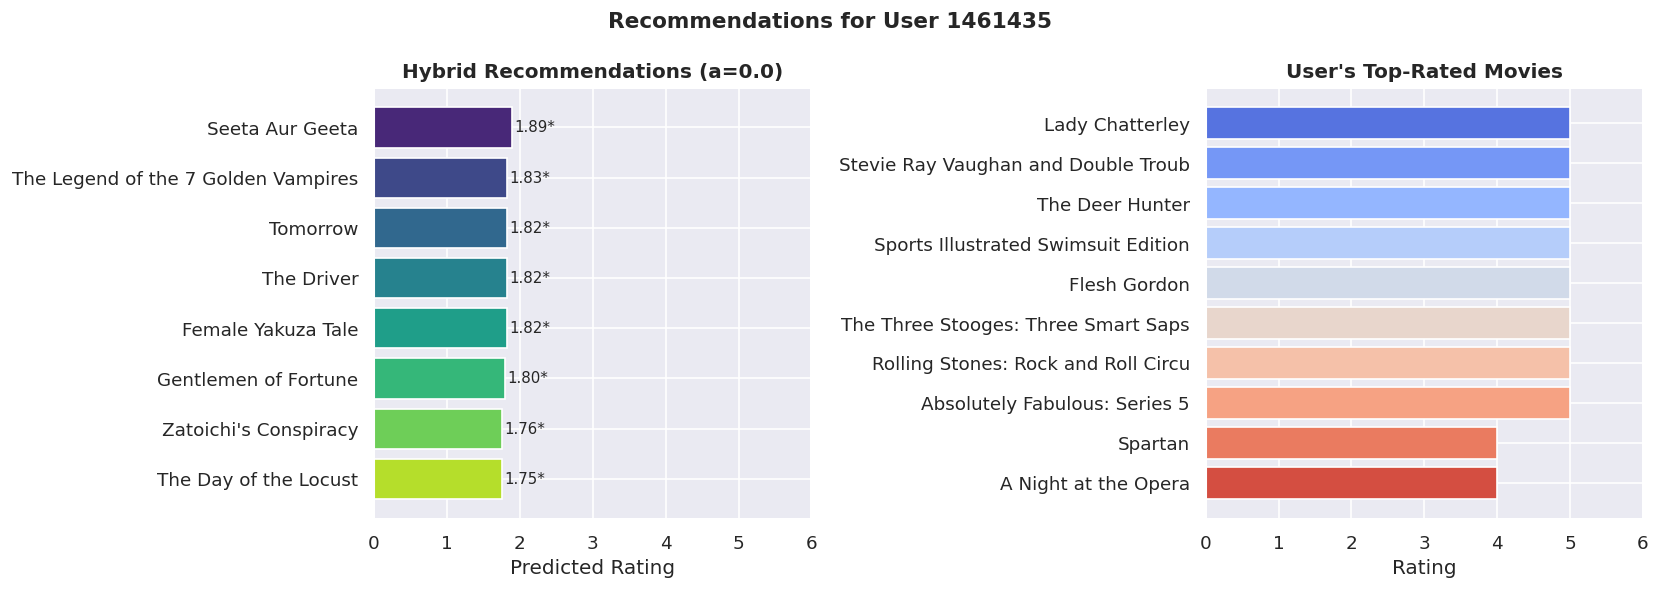

In [28]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle(f'Recommendations for User {sample_user}',fontweight='bold',fontsize=13)

ax=axes[0]
rp=recs.dropna(subset=['title']).head(10)
bars=ax.barh(rp['title'].str[:35],rp['predicted_rating'],color=sns.color_palette('viridis',len(rp)))
for bar,v in zip(bars,rp['predicted_rating']):
    ax.text(bar.get_width()+0.03,bar.get_y()+bar.get_height()/2,f'{v:.2f}*',va='center',fontsize=9)
ax.set_xlim(0,6); ax.invert_yaxis()
ax.set_title(f'Hybrid Recommendations (a={best_a:.1f})',fontweight='bold'); ax.set_xlabel('Predicted Rating')

ax=axes[1]
hist=df_f[df_f.user_id==sample_user].merge(movies[['movie_id','title']],on='movie_id',how='left')
hist=hist.nlargest(10,'rating')
ax.barh(hist['title'].fillna('Unknown').str[:35],hist['rating'],color=sns.color_palette('coolwarm',len(hist)))
ax.set_xlim(0,6); ax.invert_yaxis()
ax.set_title("User's Top-Rated Movies",fontweight='bold'); ax.set_xlabel('Rating')

plt.tight_layout(); plt.savefig('recommendations.png',bbox_inches='tight'); plt.show()

## 19. Final Summary

In [29]:
final=pd.DataFrame(all_results).drop_duplicates('Model').set_index('Model')
print('\n'+'='*65)
print('         FINAL COMPARISON — ALL 6 MODELS')
print('='*65)
print(final.to_string())
print('='*65)
print('\nBest model per metric:')
for col in final.columns:
    if col in('RMSE','MAE'): b=final[col].idxmin(); tag='lower better'
    else: b=final[col].idxmax(); tag='higher better'
    print(f'  {col:12s}: {b:40s} {final.loc[b,col]:.4f}  [{tag}]')
print('\nModel Notes:')
print('  SVD          — Fast & accurate. Netflix Prize benchmark: RMSE < 0.857')
print('  SVD++        — Extends SVD with implicit feedback (which movies rated)')
print('  KNN User     — Users like you also liked... (intuitive, slower)')
print('  KNN Item     — Similar movies to what you liked (good for item pages)')
print('  Content-Based— Works without other user data (cold-start friendly)')
print('  Hybrid       — Best of both: CF accuracy + CB cold-start handling')
print('  Knowledge-Based — Sir\'s cosine user-user CF (CP421 approach)')
print('  RL (Q-Learn) — Q-agent learns from simulated user feedback')


         FINAL COMPARISON — ALL 6 MODELS
                          RMSE     MAE  MAP@10  NDCG@10
Model                                                  
SVD                     1.0056  0.7979  0.6639   0.8449
SVD++                   0.9066  0.7102  0.7460   0.8962
KNN User-Based          0.9768  0.7720  0.6744   0.8513
KNN Item-Based          0.9971  0.7885  0.6965   0.8656
Content-Based           0.7895  0.6213  0.5481   0.8524
Hybrid (a=0.7)          0.9382  0.7429  0.5470   0.8515
Hybrid Best (a=0.0)     0.7895  0.6213  0.5481   0.8524
Knowledge-Based         1.0613  0.8354  0.6463   0.8335
Reinforcement Learning  1.8017  1.5812  0.5305   0.8403

Best model per metric:
  RMSE        : Content-Based                            0.7895  [lower better]
  MAE         : Content-Based                            0.6213  [lower better]
  MAP@10      : SVD++                                    0.7460  [higher better]
  NDCG@10     : SVD++                                    0.8962  [higher bett